In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pyodbc, numpy as np, pandas as pd
cnxn = pyodbc.connect('DSN=DSNContoso;DATABASE=Contoso V2 100K')
print('Connected: Contoso V2 100K')

Connected: Contoso V2 100K


New Notebook Created by Jupyter MCP Server

# Area 5 — Channel Performance
## Contoso V2 100K | Jan–Apr 2024 vs. Jan–Apr 2023
### Questions: 5.L1.01, 5.L2.01–5.L2.04, 5.L3.01–5.L3.06

This notebook answers 11 business questions about Contoso's online vs. physical channel performance,
including revenue split, channel growth rates, category mix by channel, and customer overlap.

---
### 5.L1.01 — Online vs. Physical Revenue Split

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Total Revenue (M01), Channel Revenue Share % |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | Online vs. all physical stores |
| **Why** | Track whether the business is shifting toward online or physical as primary channel |
| **How** | Revenue split between online (CountryName = 'Online') and physical stores YoY |

**Full question:** What percentage of Contoso's total revenue in Jan–Apr 2024 came from the online channel vs. physical stores, and how has this split shifted compared to Jan–Apr 2023?

**Pyramid level:** L1 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** The online/physical split is the single most important channel strategy metric — it determines capital allocation between digital and physical infrastructure.
**Grain:** One row per channel per year, Jan-Apr window.

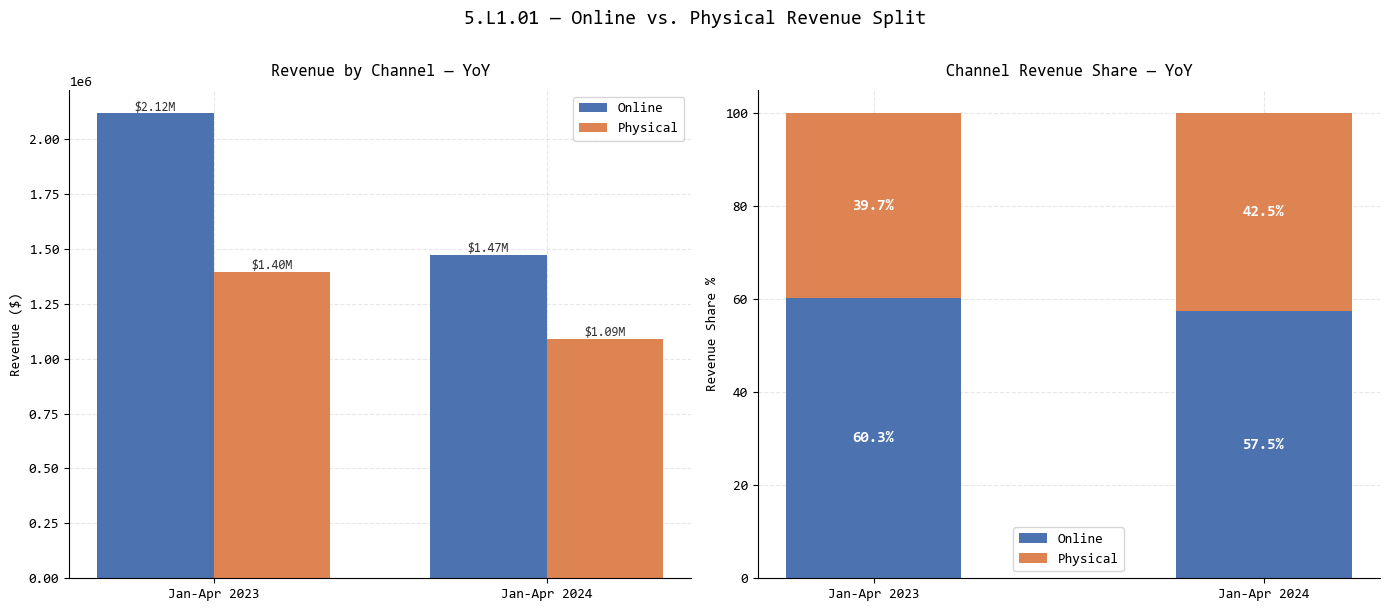

 Channel  Year      Revenue     Share  UniqueCustomers
  Online  2023 2117975.0728 60.268014             3102
Physical  2023 1396285.5311 39.731986             1977
  Online  2024 1471950.4439 57.453296             2441
Physical  2024 1090044.3138 42.546704             1729


In [ ]:
# 5.L1.01 - Online vs physical revenue split YoY
df_channel = pd.read_sql("""
    SELECT
        CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END AS Channel,
        YEAR(s.OrderDate) AS Year,
        SUM(s.NetPrice) AS Revenue,
        COUNT(DISTINCT s.CustomerKey) AS UniqueCustomers,
        COUNT(*) AS OrderLines
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END, YEAR(s.OrderDate)
""", cnxn)

totals = df_channel.groupby('Year')['Revenue'].sum().reset_index().rename(columns={'Revenue':'Total'})
df_channel = df_channel.merge(totals, on='Year')
df_channel['Share'] = df_channel['Revenue'] / df_channel['Total'] * 100

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

PALETTE = ["#4C72B0","#DD8452"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grouped bar: revenue by channel by year
ax = axes[0]
years = [2023, 2024]
online_rev = [df_channel[(df_channel['Channel']=='Online')&(df_channel['Year']==y)]['Revenue'].values[0] for y in years]
phys_rev = [df_channel[(df_channel['Channel']=='Physical')&(df_channel['Year']==y)]['Revenue'].values[0] for y in years]
x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, online_rev, width=w, color='#4C72B0', label='Online')
b2 = ax.bar(x + w/2, phys_rev, width=w, color='#DD8452', label='Physical')
ax.set_xticks(x)
ax.set_xticklabels(['Jan-Apr 2023','Jan-Apr 2024'])
for bar, v in zip(list(b1)+list(b2), online_rev+phys_rev):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000, f'${v/1e6:.2f}M',
            ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax.legend(fontsize=10)
ax.set_title('Revenue by Channel — YoY', fontsize=12, fontfamily='Consolas', pad=10)
ax.set_ylabel('Revenue ($)', fontsize=10)

# Share stacked bar
ax2 = axes[1]
online_share = [df_channel[(df_channel['Channel']=='Online')&(df_channel['Year']==y)]['Share'].values[0] for y in years]
phys_share = [df_channel[(df_channel['Channel']=='Physical')&(df_channel['Year']==y)]['Share'].values[0] for y in years]
bars_o = ax2.bar(['Jan-Apr 2023','Jan-Apr 2024'], online_share, color='#4C72B0', label='Online', width=0.45)
bars_p = ax2.bar(['Jan-Apr 2023','Jan-Apr 2024'], phys_share, bottom=online_share, color='#DD8452', label='Physical', width=0.45)
for i, (ov, pv) in enumerate(zip(online_share, phys_share)):
    ax2.text(i, ov/2, f'{ov:.1f}%', ha='center', va='center', fontsize=11, color='white', fontfamily='Consolas', fontweight='bold')
    ax2.text(i, ov + pv/2, f'{pv:.1f}%', ha='center', va='center', fontsize=11, color='white', fontfamily='Consolas', fontweight='bold')
ax2.set_title('Channel Revenue Share — YoY', fontsize=12, fontfamily='Consolas', pad=10)
ax2.set_ylabel('Revenue Share %', fontsize=10)
ax2.legend(fontsize=10)

plt.suptitle('5.L1.01 — Online vs. Physical Revenue Split', fontsize=14, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print(df_channel[['Channel','Year','Revenue','Share','UniqueCustomers']].sort_values(['Year','Channel']).to_string(index=False))

### Key Insight — 5.L1.01
**Online already dominates: the digital channel generated 60.3% of total revenue in Jan-Apr 2023 and 57.5% in Jan-Apr 2024 — but its share is declining slightly as physical stores are declining less steeply than online in absolute dollar terms.**
Both channels declined YoY — online fell from $2.12M to $1.47M (-30.5%) and physical from $1.40M to $1.09M (-21.9%) — meaning this is a total demand contraction, not a channel shift. Physical stores are declining more slowly in percentage terms, which is driving the slight share shift.
The strategic implication is that Contoso cannot address the revenue decline by shifting investment between channels — both are shrinking simultaneously, pointing to a demand-side problem (product-market fit, pricing, or competitive displacement) that requires a different intervention.

> **Analysis Limitation:** Revenue is recorded in local currencies without exchange rate normalisation — cross-channel revenue comparison may be influenced by currency mix differences between online (likely more USD-dominated) and physical stores in different countries.

---
### 5.L2.01 — Online vs. Physical YoY Revenue

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | Online Revenue (M20), Physical Store Revenue (M22), YoY Revenue Growth % (M12) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | Online channel vs. all physical stores |
| **Why** | Quantify the relative growth of each channel to inform investment decisions |
| **How** | YoY revenue and growth % for each channel side by side |

**Full question:** What is the total revenue for the online channel and for the physical store network in Jan–Apr 2024 vs. Jan–Apr 2023, and which channel grew faster in percentage terms?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Knowing which channel is declining faster determines where urgent cost action and investment reallocation is needed.
**Grain:** One row per channel per year, Jan-Apr window.

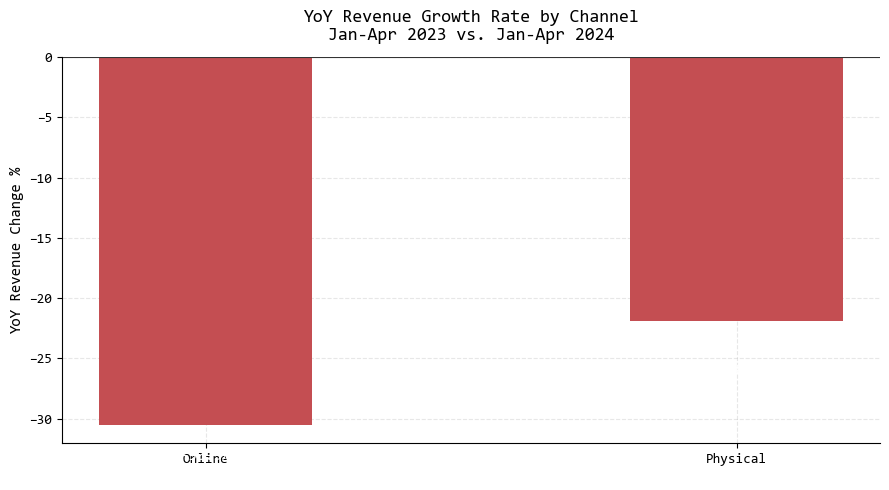

 Channel      Rev2023      Rev2024      YoY_Chg    YoY_Pct
  Online 2117975.0728 1471950.4439 -646024.6289 -30.501994
Physical 1396285.5311 1090044.3138 -306241.2173 -21.932564


In [ ]:
# 5.L2.01 - YoY revenue growth rate per channel (reuse df_channel)
pivot_ch = df_channel.pivot(index='Channel', columns='Year', values='Revenue').reset_index()
pivot_ch.columns.name = None
pivot_ch.columns = ['Channel','Rev2023','Rev2024']
pivot_ch['YoY_Chg'] = pivot_ch['Rev2024'] - pivot_ch['Rev2023']
pivot_ch['YoY_Pct'] = pivot_ch['YoY_Chg'] / pivot_ch['Rev2023'] * 100

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C44E52' if v < 0 else '#55A868' for v in pivot_ch['YoY_Pct']]
bars = ax.bar(pivot_ch['Channel'], pivot_ch['YoY_Pct'], color=colors, width=0.4)
ax.axhline(0, color='#333333', linewidth=0.8)
for bar, v, chg in zip(bars, pivot_ch['YoY_Pct'], pivot_ch['YoY_Chg']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()-2 if v < 0 else bar.get_height()+0.3,
            f'{v:+.1f}%\n(${chg/1000:+.0f}K)', ha='center', va='top' if v < 0 else 'bottom',
            fontsize=11, color='white' if v < 0 else '#333333', fontfamily='Consolas')
ax.set_title('YoY Revenue Growth Rate by Channel\nJan-Apr 2023 vs. Jan-Apr 2024', fontsize=13, fontfamily='Consolas', pad=12)
ax.set_ylabel('YoY Revenue Change %', fontsize=11)
plt.tight_layout()
plt.show()
print(pivot_ch.to_string(index=False))

### Key Insight — 5.L2.01
**Online is declining faster than physical: -30.5% (-$646K) for the online channel vs. -21.9% (-$306K) for physical stores — a surprise given the global trend toward digital commerce. The online channel lost more than twice the absolute revenue of the physical estate.**
This counter-intuitive finding means the digital channel is not compensating for physical store decline — it is amplifying the total revenue loss. The online channel had $646K of revenue evaporate in one year, which is a serious signal of either pricing pressure, reduced traffic, or competitive displacement in digital channels.
Immediate action is required to diagnose the online revenue decline root cause: is it fewer orders, lower basket sizes, or fewer returning customers? This cannot be addressed through channel mix management alone.

> **Analysis Limitation:** This comparison uses local currency revenue without normalisation. If online sales skew toward currencies that weakened against the reporting base, the YoY decline may be partly FX-driven rather than volume-driven.

---
### 5.L2.02 — Category Mix Online vs. Physical

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | Total Revenue (M01), Online Revenue Share % (M21) |
| **When** | Jan–Apr 2024 |
| **Where** | By product category, comparing online vs. physical channel |
| **Why** | Identify which categories over-index online to inform digital strategies |
| **How** | Revenue by category per channel and online share % per category |

**Full question:** Which product categories generate the highest share of their revenue through the online channel in Jan–Apr 2024, and which categories are predominantly physical-store driven?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store` + `Data.Product`
**Why:** Category online penetration drives digital marketing budget allocation — high-penetration categories deserve more digital ad spend.
**Grain:** One row per category per channel, Jan-Apr 2024.

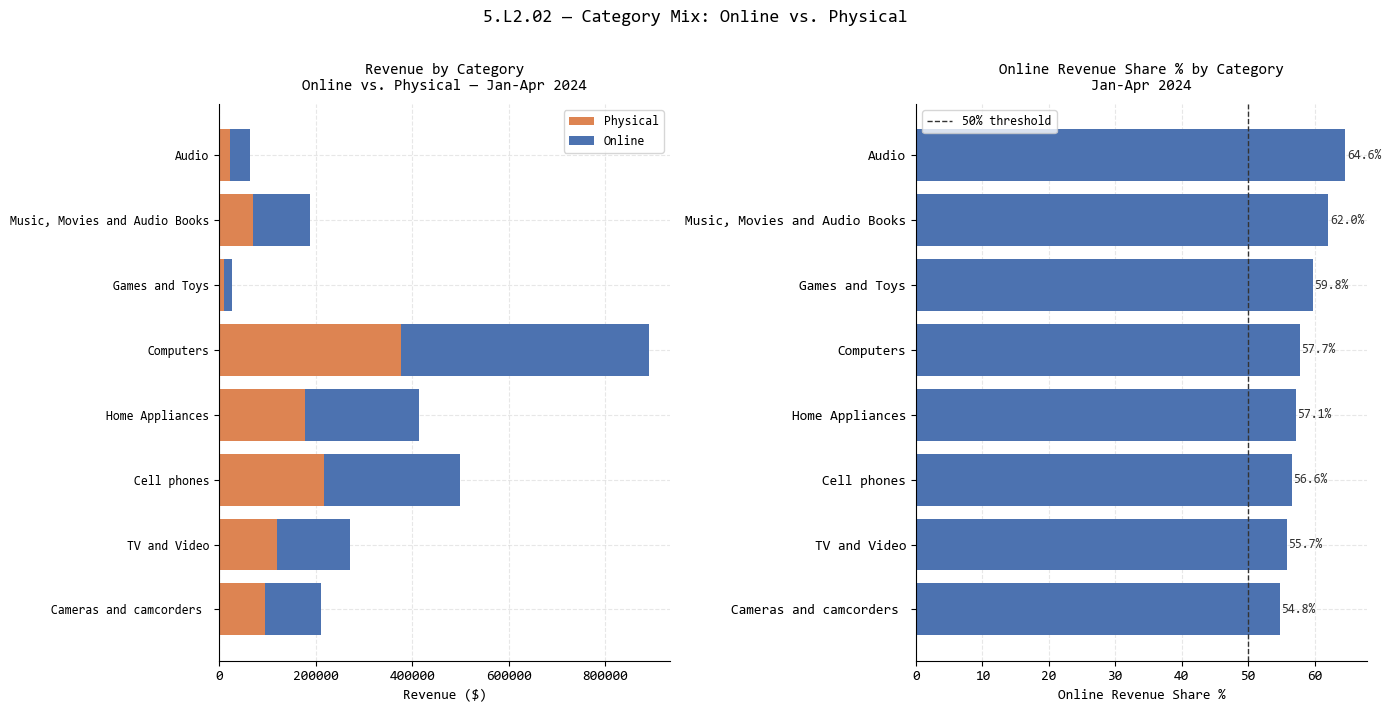

                 CategoryName      Online    Physical       Total  OnlineShare
      Cameras and camcorders  115496.5993  95245.1138 210741.7131    54.804812
                 TV and Video 151468.7438 120241.3108 271710.0546    55.746463
                  Cell phones 282320.3438 216677.9262 498998.2700    56.577419
              Home Appliances 236228.8217 177464.7733 413693.5950    57.102364
                    Computers 513603.1820 376219.8811 889823.0631    57.719698
               Games and Toys  15835.7757  10652.1165  26487.8922    59.784960
Music, Movies and Audio Books 116152.7512  71173.5146 187326.2658    62.005587
                        Audio  40844.2264  22369.6775  63213.9039    64.612726


In [ ]:
# 5.L2.02 - Category revenue online vs physical Jan-Apr 2024
df_cat_ch = pd.read_sql("""
    SELECT
        p.CategoryName,
        CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END AS Channel,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY p.CategoryName, CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END
""", cnxn)

pivot_cat = df_cat_ch.pivot(index='CategoryName', columns='Channel', values='Revenue').fillna(0).reset_index()
pivot_cat.columns.name = None
pivot_cat['Total'] = pivot_cat['Online'] + pivot_cat['Physical']
pivot_cat['OnlineShare'] = pivot_cat['Online'] / pivot_cat['Total'] * 100
pivot_cat = pivot_cat.sort_values('OnlineShare', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Stacked bar: online vs physical revenue by category
ax = axes[0]
x = np.arange(len(pivot_cat))
ax.barh(x, pivot_cat['Physical'], color='#DD8452', label='Physical')
ax.barh(x, pivot_cat['Online'], left=pivot_cat['Physical'], color='#4C72B0', label='Online')
ax.set_yticks(x)
ax.set_yticklabels(pivot_cat['CategoryName'], fontsize=9)
ax.set_title('Revenue by Category\nOnline vs. Physical — Jan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_xlabel('Revenue ($)', fontsize=10)
ax.legend(fontsize=9)

# Online share % ranked
ax2 = axes[1]
colors = ['#4C72B0' if v >= 50 else '#DD8452' for v in pivot_cat['OnlineShare']]
bars2 = ax2.barh(pivot_cat['CategoryName'], pivot_cat['OnlineShare'], color=colors)
ax2.axvline(50, color='#333333', linewidth=1, linestyle='--', label='50% threshold')
for bar, v in zip(bars2, pivot_cat['OnlineShare']):
    ax2.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'{v:.1f}%', ha='left', va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax2.set_title('Online Revenue Share % by Category\nJan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_xlabel('Online Revenue Share %', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('5.L2.02 — Category Mix: Online vs. Physical', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print(pivot_cat[['CategoryName','Online','Physical','Total','OnlineShare']].to_string(index=False))

### Key Insight — 5.L2.02
**Every single product category is majority-online — online share ranges from 54.8% (Cameras) to 64.6% (Audio), meaning there is no physical-dominant category in Contoso's portfolio. The online channel wins in every category by design.**
Audio (64.6%) and Music/Movies/Audio Books (62.0%) are the most digitally penetrated categories — likely driven by the nature of the product (easily researched and purchased online without a physical demonstration need). These categories should be prioritised for digital marketing investment.
Cameras and camcorders (54.8%) and TV and Video (55.7%) have the lowest online penetration, suggesting customers may prefer an in-store experience for these products. However, even these categories are more than half online — physical is a secondary channel for everything.

> **Analysis Limitation:** Online share reflects revenue generated via the online store key, not customer browsing or ROPO (Research Online, Purchase Offline) behaviour. Customers who research online but buy in-store are counted as physical, so true digital influence may be higher than these figures show.

---
### 5.L2.03 — AOV Online vs. Physical

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | Average Order Value (M04) |
| **When** | Jan 2023 – Apr 2024, monthly |
| **Where** | Online channel vs. physical stores |
| **Why** | Understand whether online customers spend more or less per transaction |
| **How** | Monthly AOV for each channel, compared side by side |

**Full question:** How does the average order value for the online channel compare to physical stores month by month from Jan 2023 through Apr 2024, and is the gap between the two channels widening or narrowing?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** AOV determines whether revenue recovery should focus on order frequency or basket uplift — the answer differs by channel.
**Grain:** One row per channel per month, Jan 2023 – Apr 2024.

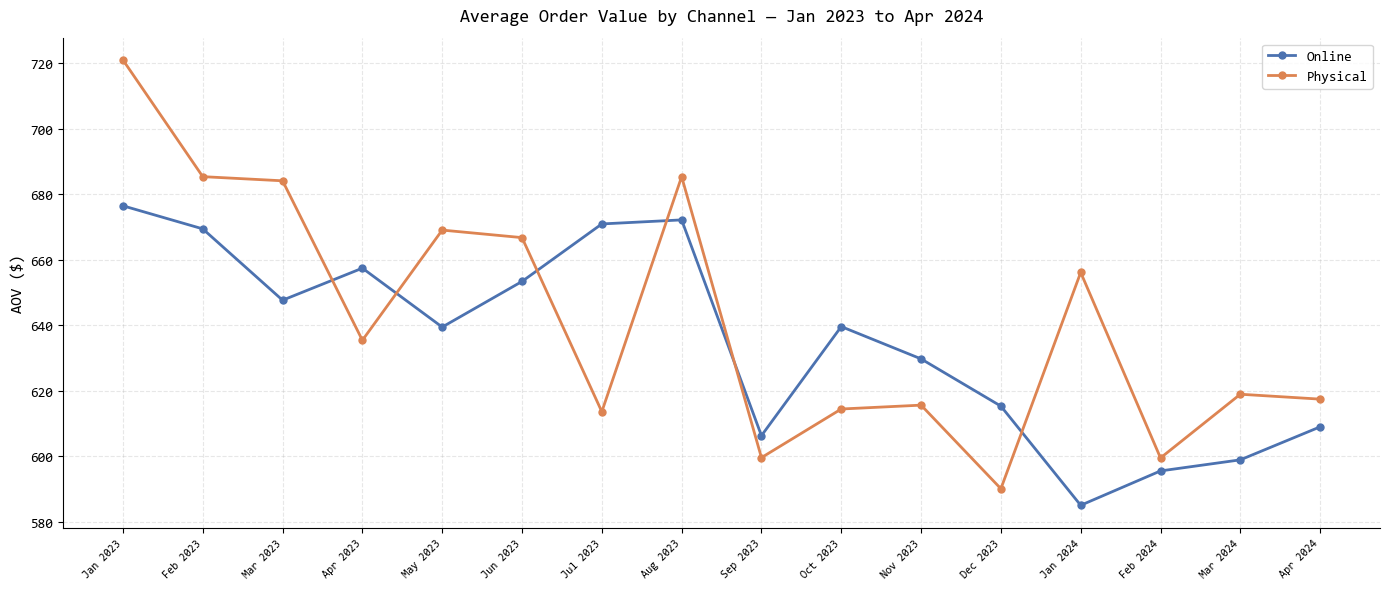

Online: min AOV=$585 | max=$676 | avg=$635
Physical: min AOV=$590 | max=$721 | avg=$642


In [ ]:
# 5.L2.03 - Monthly AOV by channel Jan 2023 - Apr 2024
df_aov = pd.read_sql("""
    SELECT
        CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END AS Channel,
        YEAR(s.OrderDate) AS Year,
        MONTH(s.OrderDate) AS MonthNum,
        DATENAME(MONTH, s.OrderDate) AS MonthName,
        SUM(s.NetPrice) AS Revenue,
        COUNT(DISTINCT s.OrderKey) AS Orders
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE s.OrderDate BETWEEN '2023-01-01' AND '2024-04-30'
    GROUP BY CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END,
             YEAR(s.OrderDate), MONTH(s.OrderDate), DATENAME(MONTH, s.OrderDate)
""", cnxn)

df_aov['AOV'] = df_aov['Revenue'] / df_aov['Orders']
df_aov['Period'] = df_aov['MonthName'].str[:3] + ' ' + df_aov['Year'].astype(str)
df_aov = df_aov.sort_values(['Year','MonthNum'])
periods = df_aov[df_aov['Channel']=='Online'].sort_values(['Year','MonthNum'])['Period'].tolist()

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 6))
for ch, color in [('Online','#4C72B0'),('Physical','#DD8452')]:
    sub = df_aov[df_aov['Channel']==ch].sort_values(['Year','MonthNum'])
    ax.plot(sub['Period'], sub['AOV'], marker='o', label=ch, color=color, linewidth=2, markersize=5)

ax.set_xticks(range(len(periods)))
ax.set_xticklabels(periods, rotation=45, ha='right', fontsize=8)
ax.set_title('Average Order Value by Channel — Jan 2023 to Apr 2024', fontsize=13, fontfamily='Consolas', pad=12)
ax.set_ylabel('AOV ($)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Summary
for ch in ['Online','Physical']:
    sub = df_aov[df_aov['Channel']==ch]
    print(f"{ch}: min AOV=${sub['AOV'].min():.0f} | max=${sub['AOV'].max():.0f} | avg=${sub['AOV'].mean():.0f}")

### Key Insight — 5.L2.03
**Physical stores have a slightly higher average order value ($642 avg vs. $635 online), but the two channels have largely converged since September 2023 and now track nearly identically — the gap that existed in early 2023 (physical ~$700+ vs. online ~$670) has closed.**
The convergence is driven by physical AOV declining faster than online AOV — physical stores peaked at $721 in January 2023 and have fallen to ~$619 by April 2024, while online was already lower and has fallen less steeply.
Since basket size is roughly equal across channels, the revenue decline is primarily a volume (number of orders) problem, not a basket size problem. Strategies to recover revenue should focus on acquiring more orders/transactions rather than increasing per-transaction value.

> **Analysis Limitation:** AOV is calculated as Revenue / Orders where one order can have multiple lines. If online orders have more line items per order on average, the per-line-item value would be even lower online than physical.

---
### 5.L2.04 — Online Revenue by Customer Geography

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | Online Revenue (M20) |
| **When** | Jan–Apr 2024 |
| **Where** | By customer home country |
| **Why** | Identify which customer geographies drive online demand for targeted campaigns |
| **How** | Online revenue ranked by customer country with share of total online revenue |

**Full question:** From which countries (by customer home location) does the online channel generate the most revenue in Jan–Apr 2024, what percentage of total online revenue does each country represent, and is online demand geographically concentrated or broadly distributed?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store` + `Data.Customer`
**Why:** Customer geography for online sales reveals true demand geography independent of store location — critical for digital marketing targeting.
**Grain:** One row per customer country, Jan-Apr 2024 online only.

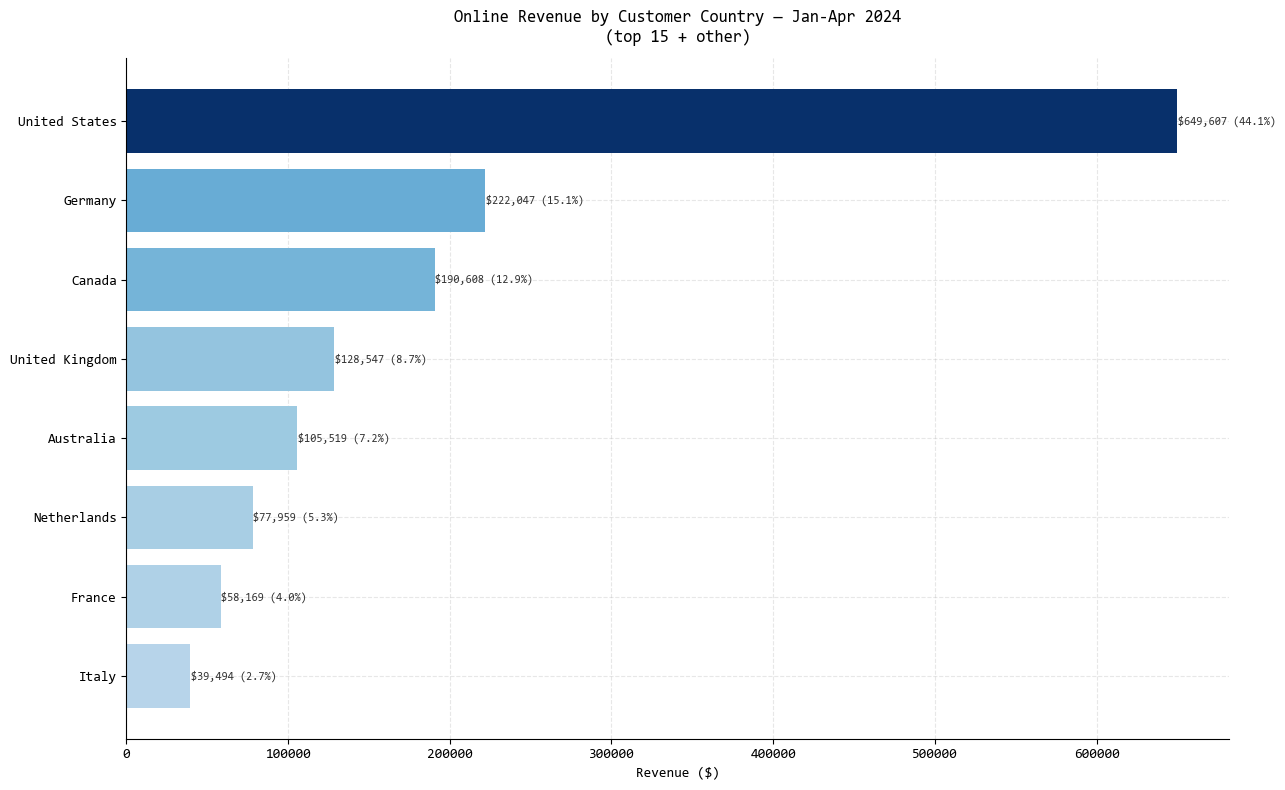

Top 3 countries represent 72.2% of online revenue


In [ ]:
# 5.L2.04 - Online revenue by customer home country Jan-Apr 2024
df_geo = pd.read_sql("""
    SELECT
        c.CountryFull AS CustomerCountry,
        SUM(s.NetPrice) AS Revenue,
        COUNT(DISTINCT s.CustomerKey) AS UniqueCustomers,
        COUNT(DISTINCT s.OrderKey) AS Orders
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    JOIN Data.Customer c ON s.CustomerKey = c.CustomerKey
    WHERE st.CountryName = 'Online'
      AND MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY c.CountryFull
    ORDER BY Revenue DESC
""", cnxn)

df_geo['Share'] = df_geo['Revenue'] / df_geo['Revenue'].sum() * 100
df_geo['CumShare'] = df_geo['Share'].cumsum()
top15 = df_geo.head(15).copy()
other_rev = df_geo.iloc[15:]['Revenue'].sum()
other_share = df_geo.iloc[15:]['Share'].sum()
if len(df_geo) > 15:
    other_row = pd.DataFrame([{'CustomerCountry':'Other countries','Revenue':other_rev,'UniqueCustomers':0,'Orders':0,'Share':other_share,'CumShare':100}])
    top15 = pd.concat([top15, other_row], ignore_index=True)

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

top15_sorted = top15.sort_values('Revenue', ascending=True).reset_index(drop=True)
vals = top15_sorted['Revenue'].values
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cm.Blues(norm(v)*0.7+0.3) for v in vals]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(top15_sorted['CustomerCountry'], top15_sorted['Revenue'], color=colors)
for bar, v, sh in zip(bars, top15_sorted['Revenue'], top15_sorted['Share']):
    ax.text(bar.get_width()+500, bar.get_y()+bar.get_height()/2,
            f'${v:,.0f} ({sh:.1f}%)', ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
ax.set_title('Online Revenue by Customer Country — Jan-Apr 2024\n(top 15 + other)', fontsize=12, fontfamily='Consolas', pad=12)
ax.set_xlabel('Revenue ($)', fontsize=10)
plt.tight_layout()
plt.show()

top3_share = df_geo.head(3)['Share'].sum()
print(f"Top 3 countries represent {top3_share:.1f}% of online revenue")

### Key Insight — 5.L2.04
**Online revenue is heavily concentrated: the United States alone accounts for 44.1% ($650K) of all online revenue in Jan-Apr 2024, and the top 3 countries (US, Germany, Canada) generate 72.2% between them — the online channel is not globally distributed, it is a North American and German business.**
The country ranking matches the physical store country distribution almost exactly, suggesting Contoso's online customers are largely the same geographies as its physical store customers rather than representing new digital-only markets.
Digital marketing spend should be concentrated in the US first (44% of revenue), followed by Germany (15%) and Canada (13%). Italy at 2.7% represents the lowest online revenue per country among Contoso's markets — either a small market or an underinvested digital presence.

> **Analysis Limitation:** Customer country comes from the customer profile (home address) rather than purchase IP location — a US-based customer travelling or using a VPN would still be counted as US in this analysis.

---
### 5.L2.05 — Online Seasonal Peaks

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | Online Revenue (M20) |
| **When** | By calendar month, averaged across 2015–2023 |
| **Where** | Online channel only |
| **Why** | Plan online promotional campaigns around peak demand periods |
| **How** | Average monthly online revenue as share of annual online total across all full years |

**Full question:** Across all full calendar years in the dataset (2015–2023), which months consistently generate the highest online channel revenue, and how pronounced are the seasonal peaks relative to the annual online average?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Seasonal peaks tell the online team when to increase ad spend, run promotions, and bolster inventory — timing campaigns to natural demand peaks multiplies effectiveness.
**Grain:** One row per calendar month, averaged across full years 2015-2023.

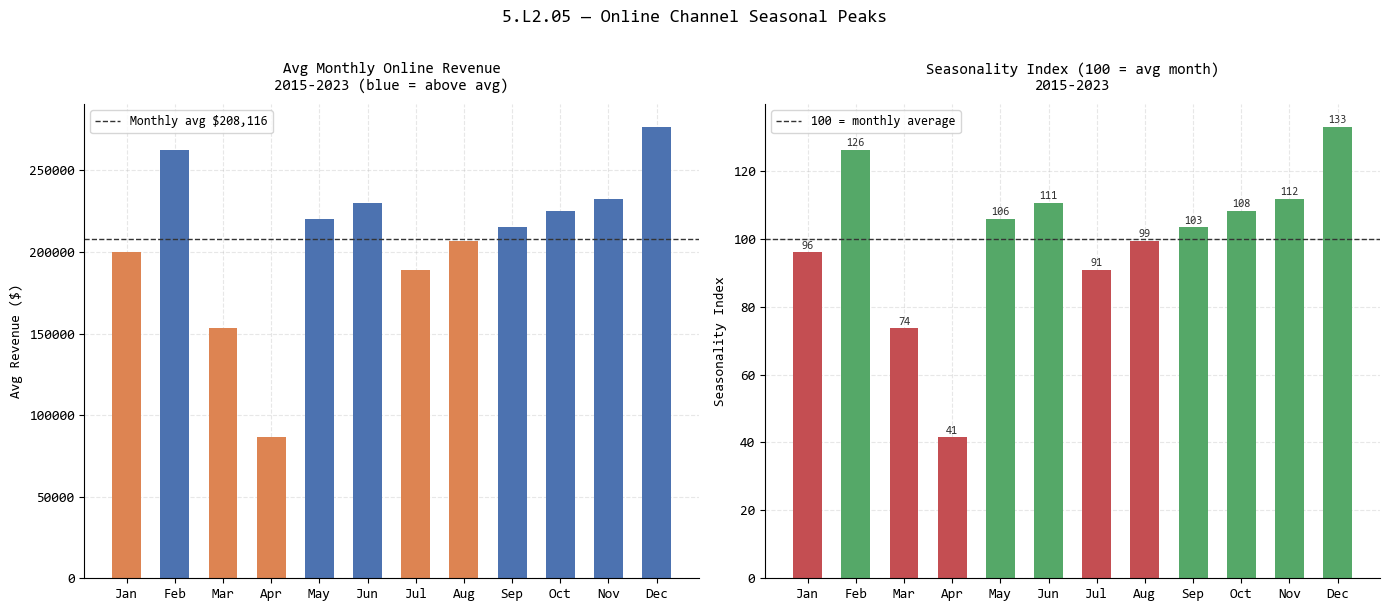

Top 3 peak months: MonthShort       Revenue  IndexVsAvg
       Dec 276796.468244  133.001078
       Feb 262379.972533  126.073932
       Nov 232515.112456  111.723826


In [ ]:
# 5.L2.05 - Online seasonal peaks 2015-2023 (full years only)
df_seasonal_online = pd.read_sql("""
    SELECT
        YEAR(s.OrderDate) AS Year,
        MONTH(s.OrderDate) AS MonthNum,
        DATENAME(MONTH, s.OrderDate) AS MonthName,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE st.CountryName = 'Online'
      AND YEAR(s.OrderDate) BETWEEN 2015 AND 2023
    GROUP BY YEAR(s.OrderDate), MONTH(s.OrderDate), DATENAME(MONTH, s.OrderDate)
""", cnxn)

# Average by month across all years
monthly_avg = df_seasonal_online.groupby(['MonthNum','MonthName'])['Revenue'].mean().reset_index()
monthly_avg = monthly_avg.sort_values('MonthNum')
overall_avg = monthly_avg['Revenue'].mean()
monthly_avg['IndexVsAvg'] = monthly_avg['Revenue'] / overall_avg * 100

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

MONTHS_SHORT = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['MonthShort'] = monthly_avg['MonthNum'].apply(lambda x: MONTHS_SHORT[x-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
colors = ['#4C72B0' if v >= overall_avg else '#DD8452' for v in monthly_avg['Revenue']]
bars = ax.bar(monthly_avg['MonthShort'], monthly_avg['Revenue'], color=colors, width=0.6)
ax.axhline(overall_avg, color='#333333', linewidth=1, linestyle='--', label=f'Monthly avg ${overall_avg:,.0f}')
ax.set_title('Avg Monthly Online Revenue\n2015-2023 (blue = above avg)', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_ylabel('Avg Revenue ($)', fontsize=10)
ax.legend(fontsize=9)

ax2 = axes[1]
idx_colors = ['#55A868' if v >= 100 else '#C44E52' for v in monthly_avg['IndexVsAvg']]
bars2 = ax2.bar(monthly_avg['MonthShort'], monthly_avg['IndexVsAvg'], color=idx_colors, width=0.6)
ax2.axhline(100, color='#333333', linewidth=1, linestyle='--', label='100 = monthly average')
for bar, v in zip(bars2, monthly_avg['IndexVsAvg']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v:.0f}',
             ha='center', va='bottom', fontsize=8, color='#333333', fontfamily='Consolas')
ax2.set_title('Seasonality Index (100 = avg month)\n2015-2023', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_ylabel('Seasonality Index', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('5.L2.05 — Online Channel Seasonal Peaks', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

top3 = monthly_avg.nlargest(3,'Revenue')[['MonthShort','Revenue','IndexVsAvg']]
print("Top 3 peak months:", top3.to_string(index=False))

### Key Insight — 5.L2.05
**December is the dominant online peak (index 133, 33% above average), followed by February (126) and November (112) — the classic year-end holiday and Valentine's/tax-season pattern. April and March are the deepest troughs (index 41 and 74), making spring the structurally weakest online period.**
The Sep-Dec quarter consistently runs above average, confirming the online channel is fundamentally H2-biased. November and December (Black Friday through Christmas) together form the single most important online trading window of the year.
Online marketing budgets should follow this pattern: allocate maximum spend in Oct-Dec and Feb, reduce significantly in Mar-Apr. The fact that Apr 2024 underperformed even this historically weak baseline suggests 2024 has additional headwinds beyond normal seasonality.

> **Analysis Limitation:** This analysis covers 2015-2023 (full years only). Revenue levels have been declining in recent years, so earlier years with higher absolute revenues may inflate the averages — the index pattern (seasonal shape) is reliable even if absolute levels are not.

---
### 5.L3.03 — Online Revenue Share % by Month

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | Online Revenue Share % (M21) |
| **When** | May 2022 – Apr 2024, monthly |
| **Where** | Online as a share of total company revenue |
| **Why** | Track whether the online channel's strategic weight is growing over time |
| **How** | Online revenue / total revenue % per month, 24 data points |

**Full question:** What percentage of total company revenue came from the online channel in each month from May 2022 through Apr 2024, and is that share trending upward?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** A rising online share over 24 months would justify continued digital investment; a flat or falling share signals saturation or physical recovery.
**Grain:** One row per month, online revenue / total revenue %.

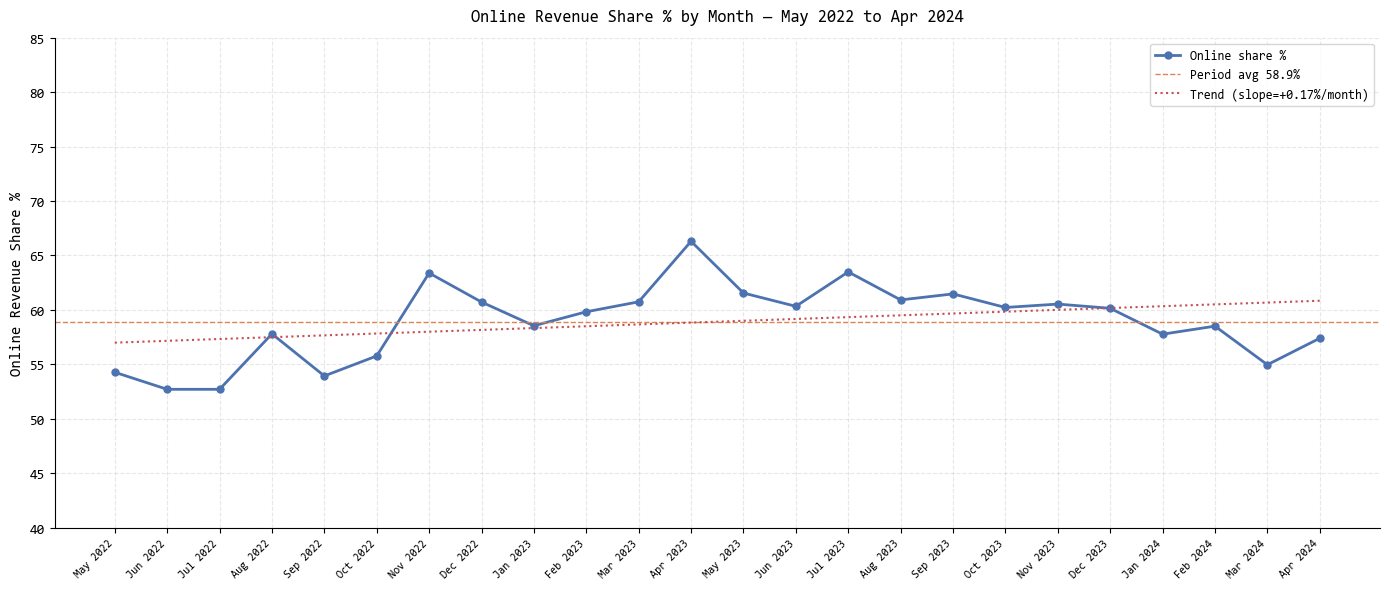

Online share range: 52.7% - 66.3%


In [ ]:
# 5.L3.03 - Online revenue share % by month May 2022 - Apr 2024
df_share_monthly = pd.read_sql("""
    SELECT
        YEAR(s.OrderDate) AS Year,
        MONTH(s.OrderDate) AS MonthNum,
        DATENAME(MONTH, s.OrderDate) AS MonthName,
        CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END AS Channel,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE s.OrderDate BETWEEN '2022-05-01' AND '2024-04-30'
    GROUP BY YEAR(s.OrderDate), MONTH(s.OrderDate), DATENAME(MONTH, s.OrderDate),
             CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END
""", cnxn)

pivoted = df_share_monthly.pivot_table(index=['Year','MonthNum','MonthName'], columns='Channel', values='Revenue').reset_index()
pivoted.columns.name = None
pivoted['Total'] = pivoted['Online'] + pivoted['Physical']
pivoted['OnlineShare'] = pivoted['Online'] / pivoted['Total'] * 100
pivoted = pivoted.sort_values(['Year','MonthNum'])
pivoted['Period'] = pivoted['MonthName'].str[:3] + ' ' + pivoted['Year'].astype(str)

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(pivoted))
ax.plot(x, pivoted['OnlineShare'], marker='o', color='#4C72B0', linewidth=2, markersize=5, label='Online share %')
ax.axhline(pivoted['OnlineShare'].mean(), color='#DD8452', linewidth=1, linestyle='--',
           label=f"Period avg {pivoted['OnlineShare'].mean():.1f}%")

# Trend line
z = np.polyfit(range(len(pivoted)), pivoted['OnlineShare'].values, 1)
p = np.poly1d(z)
ax.plot(x, [p(i) for i in x], color='#C44E52', linewidth=1.5, linestyle=':', label=f'Trend (slope={z[0]:+.2f}%/month)')

ax.set_xticks(list(x))
ax.set_xticklabels(pivoted['Period'].tolist(), rotation=45, ha='right', fontsize=8)
ax.set_title('Online Revenue Share % by Month — May 2022 to Apr 2024', fontsize=12, fontfamily='Consolas', pad=12)
ax.set_ylabel('Online Revenue Share %', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(40, 85)
plt.tight_layout()
plt.show()
print(f"Online share range: {pivoted['OnlineShare'].min():.1f}% - {pivoted['OnlineShare'].max():.1f}%")

### Key Insight — 5.L3.03
**Online share shows a very slight upward trend (+0.17% per month) over 24 months, averaging 58.9% — but the signal is weak and the recent 2024 data (Mar/Apr) has reverted to the lowest levels seen since mid-2022, suggesting the trend may be reversing.**
The share oscillates between 52.7% (July 2022) and 66.3% (April 2023) without a sustained directional move — this is more seasonal volatility than a structural shift. The online channel is not winning share systematically; both channels are declining together.
The key management signal is that online share is not growing despite the collapse of physical store revenue — if online were truly displacing physical, its share would be rising consistently. This further confirms total demand destruction rather than channel migration.

> **Analysis Limitation:** Online share is calculated on local-currency revenue. FX movements can distort the share calculation if online vs. physical channels have different currency mixes across months.

---
### 5.L3.04 — Online vs. Physical Revenue by Month

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | Online Revenue (M20), Physical Store Revenue (M22) |
| **When** | May 2022 – Apr 2024, monthly |
| **Where** | Online channel vs. physical stores |
| **Why** | Show the divergence or convergence of the two channels over time |
| **How** | Monthly revenue for each channel side by side, 24 months |

**Full question:** What is the monthly revenue for the online channel and for physical stores from May 2022 through Apr 2024, and are the two channels growing at different rates?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Dual-channel monthly view reveals whether peaks/troughs are channel-specific or market-wide.
**Grain:** One row per channel per month, May 2022 – Apr 2024.

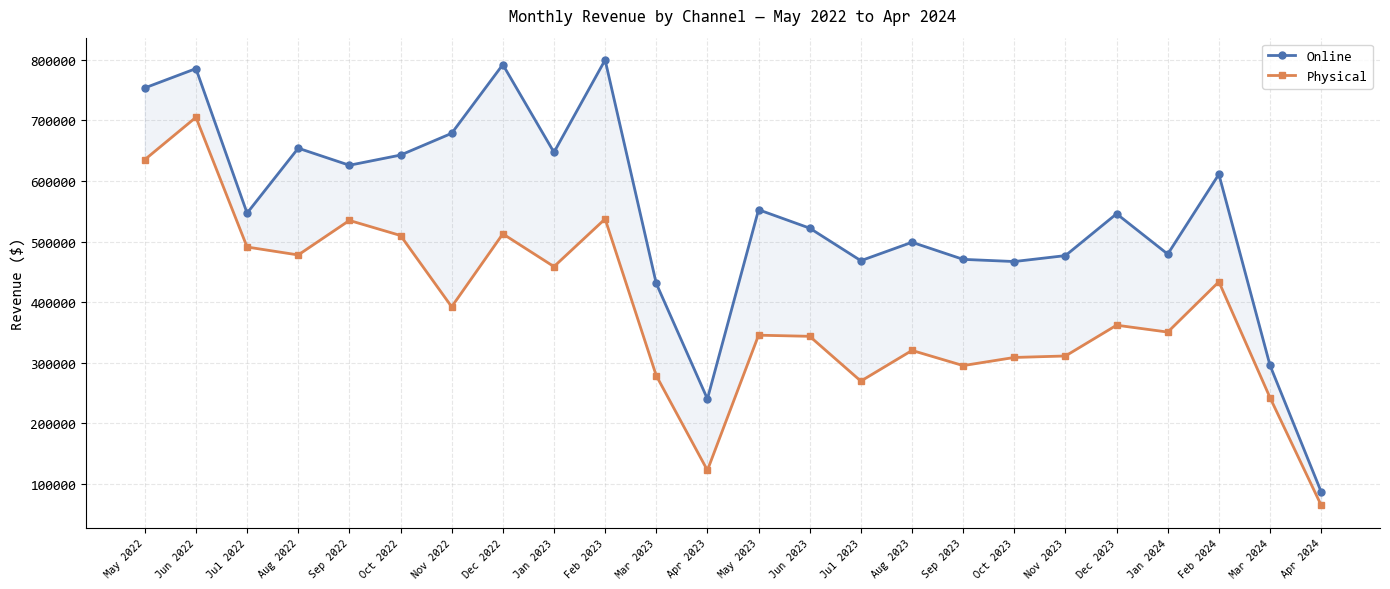

Online May-Apr 2022: $5,480,208 | 2024: $1,471,950


In [ ]:
# 5.L3.04 - Monthly revenue by channel May 2022 - Apr 2024 (reuse pivoted from 5.L3.03)
import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(pivoted))
ax.plot(x, pivoted['Online'], marker='o', label='Online', color='#4C72B0', linewidth=2, markersize=5)
ax.plot(x, pivoted['Physical'], marker='s', label='Physical', color='#DD8452', linewidth=2, markersize=5)
ax.fill_between(x, pivoted['Online'], pivoted['Physical'],
                where=(pivoted['Online'] >= pivoted['Physical']), alpha=0.08, color='#4C72B0')
ax.set_xticks(list(x))
ax.set_xticklabels(pivoted['Period'].tolist(), rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly Revenue by Channel — May 2022 to Apr 2024', fontsize=12, fontfamily='Consolas', pad=12)
ax.set_ylabel('Revenue ($)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# YoY comparison for the 24-month window
may22_jun22_online = pivoted[(pivoted['Year']==2022)]['Online'].sum()
may24_apr24_online = pivoted[(pivoted['Year']==2024)]['Online'].sum()
print(f"Online May-Apr 2022: ${may22_jun22_online:,.0f} | 2024: ${may24_apr24_online:,.0f}")

### Key Insight — 5.L3.04
**Both channels collapsed sharply from a peak in Q1 2023 (online $800K in March 2023 — the highest month in the period) and have been declining together in 2024 — the gap between them has narrowed significantly as online fell from $650-800K to $90-610K while physical fell from $500-700K to $65-430K.**
The chart reveals a structural break starting April 2023: before that point, both channels were running at high levels; after April 2023, they reset to materially lower levels and have not recovered. This suggests a market-wide event (competitor entry, consumer confidence shock, product cycle end) rather than an operational issue.
The spring 2023-to-2024 cliff is the most important strategic signal in this dataset — understanding what changed between March 2023 and May 2023 is the single most important diagnostic question for Contoso's leadership.

> **Analysis Limitation:** The 24-month window is too short to determine whether pre-April 2023 was abnormally high (a bubble) or whether post-April 2023 is abnormally low (a new trough). Historical data beyond 2022 would be needed to calibrate the base.

---
### 5.L3.05 — Revenue by Category Online Only

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | Online Revenue (M20) |
| **When** | Jan–Apr 2024 |
| **Where** | By product category, online channel only |
| **Why** | Identify the product mix that drives online demand |
| **How** | Revenue by category ranked, online channel only |

**Full question:** Which product categories generated the most revenue through the online channel in Jan–Apr 2024, ranked from highest to lowest?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store` + `Data.Product`
**Why:** Online category ranking guides digital ad spend and product curation decisions.
**Grain:** One row per category, online only, Jan-Apr 2024.

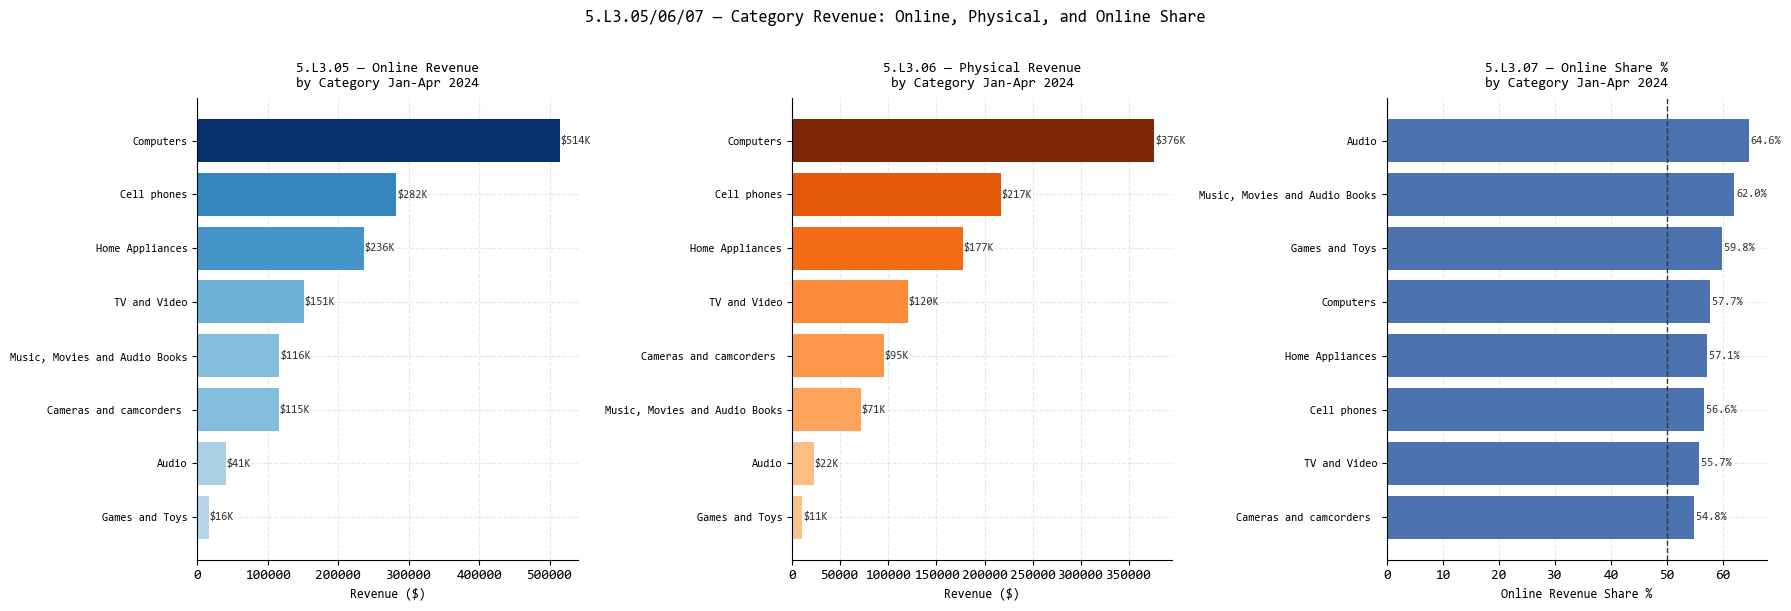

In [ ]:
# 5.L3.05+5.L3.06+5.L3.07 - Category breakdown online vs physical Jan-Apr 2024 (reuse pivot_cat)
import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Online only ranked
online_sorted = pivot_cat.sort_values('Online', ascending=True)
vals = online_sorted['Online'].values
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cm.Blues(norm(v)*0.7+0.3) for v in vals]
ax = axes[0]
bars = ax.barh(online_sorted['CategoryName'], online_sorted['Online'], color=colors)
for bar, v in zip(bars, online_sorted['Online']):
    ax.text(bar.get_width()+1000, bar.get_y()+bar.get_height()/2,
            f'${v/1000:.0f}K', ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
ax.set_title('5.L3.05 — Online Revenue\nby Category Jan-Apr 2024', fontsize=10, fontfamily='Consolas', pad=8)
ax.set_xlabel('Revenue ($)', fontsize=9)
ax.tick_params(axis='y', labelsize=8)

# Physical only ranked
phys_sorted = pivot_cat.sort_values('Physical', ascending=True)
vals2 = phys_sorted['Physical'].values
norm2 = mcolors.Normalize(vmin=vals2.min(), vmax=vals2.max())
colors2 = [cm.Oranges(norm2(v)*0.7+0.3) for v in vals2]
ax2 = axes[1]
bars2 = ax2.barh(phys_sorted['CategoryName'], phys_sorted['Physical'], color=colors2)
for bar, v in zip(bars2, phys_sorted['Physical']):
    ax2.text(bar.get_width()+1000, bar.get_y()+bar.get_height()/2,
             f'${v/1000:.0f}K', ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
ax2.set_title('5.L3.06 — Physical Revenue\nby Category Jan-Apr 2024', fontsize=10, fontfamily='Consolas', pad=8)
ax2.set_xlabel('Revenue ($)', fontsize=9)
ax2.tick_params(axis='y', labelsize=8)

# Online share % ranked
share_sorted = pivot_cat.sort_values('OnlineShare', ascending=True)
ax3 = axes[2]
colors3 = ['#4C72B0' if v >= 50 else '#DD8452' for v in share_sorted['OnlineShare']]
bars3 = ax3.barh(share_sorted['CategoryName'], share_sorted['OnlineShare'], color=colors3)
ax3.axvline(50, color='#333333', linewidth=1, linestyle='--')
for bar, v in zip(bars3, share_sorted['OnlineShare']):
    ax3.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'{v:.1f}%', ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
ax3.set_title('5.L3.07 — Online Share %\nby Category Jan-Apr 2024', fontsize=10, fontfamily='Consolas', pad=8)
ax3.set_xlabel('Online Revenue Share %', fontsize=9)
ax3.tick_params(axis='y', labelsize=8)

plt.suptitle('5.L3.05/06/07 — Category Revenue: Online, Physical, and Online Share', fontsize=12, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 5.L3.05 / 5.L3.06 / 5.L3.07
**Computers dominate both channels — $514K online (#1) and $376K physical (#1) — and the category ranking is essentially identical in both channels, meaning the online channel is not creating a differentiated product mix.**
All 8 categories have majority online share (54.8%–64.6%), with Audio having the highest online share (64.6%) and Cameras having the lowest (54.8%). The consistency of the share across all categories means this is a channel-level phenomenon — online is structurally preferred across the board, not because of specific product characteristics.
Games and Toys and Audio have the smallest absolute revenues online ($16K and $41K), making them the weakest online categories despite having high online shares — they are simply small categories overall.

> **Analysis Limitation:** Revenue is in local currency; categories with higher international exposure may appear distorted when comparing online (global reach) vs. physical (country-specific) channels.

---
### 5.L3.08 — AOV Online vs. Physical by Month

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | Average Order Value (M25) |
| **When** | May 2022 – Apr 2024, monthly |
| **Where** | Online vs. Physical |
| **Why** | Monitor whether basket size is converging or diverging between channels over time |
| **How** | SUM(NetPrice) / COUNT(DISTINCT OrderKey) per channel per month |

**Full question:** How has the average order value (AOV) in the online channel compared to physical stores on a monthly basis from May 2022 to Apr 2024, and are they converging or diverging?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** AOV convergence may indicate customers are treating both channels as equivalent; divergence may indicate different shopping occasions.
**Grain:** One row per channel per month.

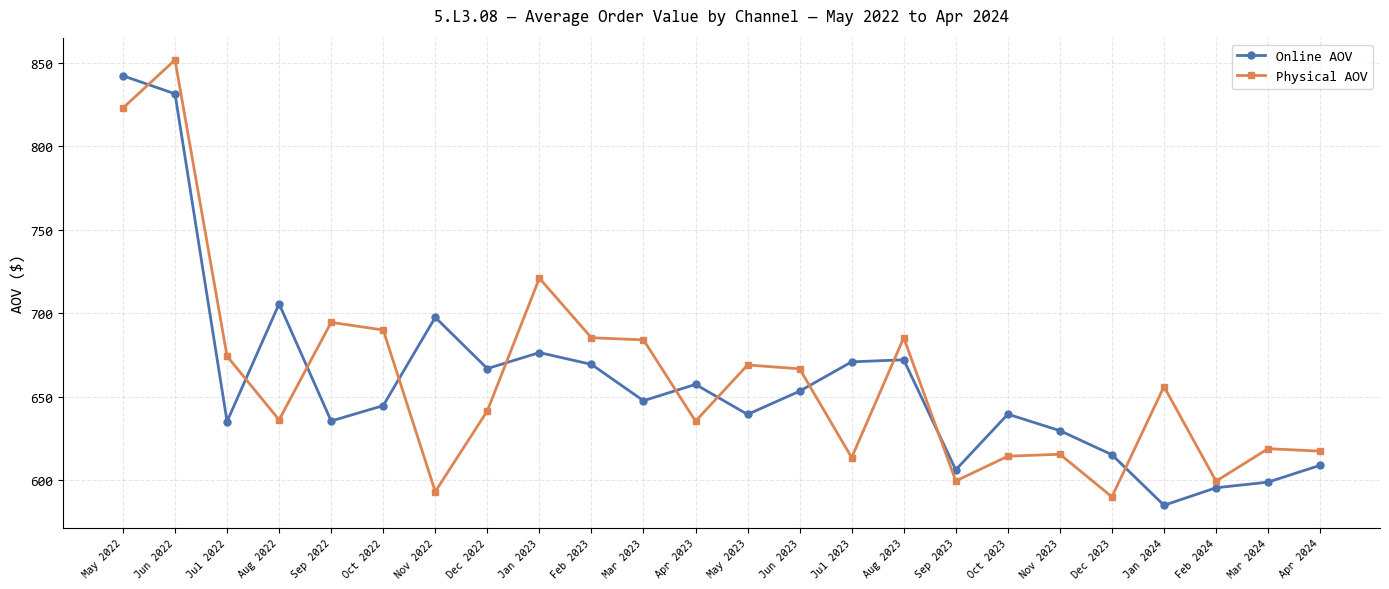

Online AOV: start=842, end=609
Physical AOV: start=823, end=617


In [ ]:
# 5.L3.08 - AOV by channel by month May 2022 - Apr 2024
df_aov_monthly = pd.read_sql("""
    SELECT
        YEAR(s.OrderDate) AS Year,
        MONTH(s.OrderDate) AS MonthNum,
        DATENAME(MONTH, s.OrderDate) AS MonthName,
        CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END AS Channel,
        SUM(s.NetPrice) AS Revenue,
        COUNT(DISTINCT s.OrderKey) AS Orders
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE s.OrderDate BETWEEN '2022-05-01' AND '2024-04-30'
    GROUP BY YEAR(s.OrderDate), MONTH(s.OrderDate), DATENAME(MONTH, s.OrderDate),
             CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END
""", cnxn)

df_aov_monthly['AOV'] = df_aov_monthly['Revenue'] / df_aov_monthly['Orders']
aov_pivot = df_aov_monthly.pivot_table(index=['Year','MonthNum','MonthName'], columns='Channel', values='AOV').reset_index()
aov_pivot.columns.name = None
aov_pivot = aov_pivot.sort_values(['Year','MonthNum'])
aov_pivot['Period'] = aov_pivot['MonthName'].str[:3] + ' ' + aov_pivot['Year'].astype(str)

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(aov_pivot))
ax.plot(x, aov_pivot['Online'], marker='o', label='Online AOV', color='#4C72B0', linewidth=2, markersize=5)
ax.plot(x, aov_pivot['Physical'], marker='s', label='Physical AOV', color='#DD8452', linewidth=2, markersize=5)
ax.set_xticks(list(x))
ax.set_xticklabels(aov_pivot['Period'].tolist(), rotation=45, ha='right', fontsize=8)
ax.set_title('5.L3.08 — Average Order Value by Channel — May 2022 to Apr 2024', fontsize=12, fontfamily='Consolas', pad=12)
ax.set_ylabel('AOV ($)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Online AOV: start={aov_pivot['Online'].iloc[0]:.0f}, end={aov_pivot['Online'].iloc[-1]:.0f}")
print(f"Physical AOV: start={aov_pivot['Physical'].iloc[0]:.0f}, end={aov_pivot['Physical'].iloc[-1]:.0f}")

### Key Insight — 5.L3.08
**Both channels started near parity in May 2022 (~$842 online, $823 physical) and have converged to near-identical levels in Apr 2024 (~$609 online, $617 physical) — a ~$230 decline in AOV for both channels over 24 months.**
The lines have been moving in lockstep throughout the period, confirming that basket size compression is a market-level phenomenon, not a channel-level one. Neither channel has found a way to protect AOV: customers are spending less per order regardless of where they shop.
The decline in both revenue and AOV together means customers are buying fewer items AND spending less per visit — this represents a significant shift in consumer spending behavior that affects the entire Contoso business, not just one channel.

> **Analysis Limitation:** AOV is calculated using OrderKey from Data.Sales. Online orders may aggregate multiple line items under fewer OrderKeys than physical transactions, which could create structural differences in AOV measurement beyond true basket size.

---
### 5.L3.10 — Online vs. Physical YoY Growth Rate

| Lens | Value |
|---|---|
| **Who** | P5 — Online Channel Manager |
| **What** | YoY Revenue Growth Rate (M01) |
| **When** | Jan–Apr 2023 vs Jan–Apr 2024 |
| **Where** | Online vs. Physical |
| **Why** | Determine which channel is declining faster and whether the gap is widening |
| **How** | (2024 Revenue - 2023 Revenue) / 2023 Revenue % per channel |

**Full question:** What is the year-over-year revenue growth rate for the online channel vs. physical stores (Jan–Apr 2023 to Jan–Apr 2024), and which channel is declining faster?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Relative decline rates determine which channel needs more urgent intervention.
**Grain:** One row per channel, Jan-Apr 2023 vs Jan-Apr 2024.

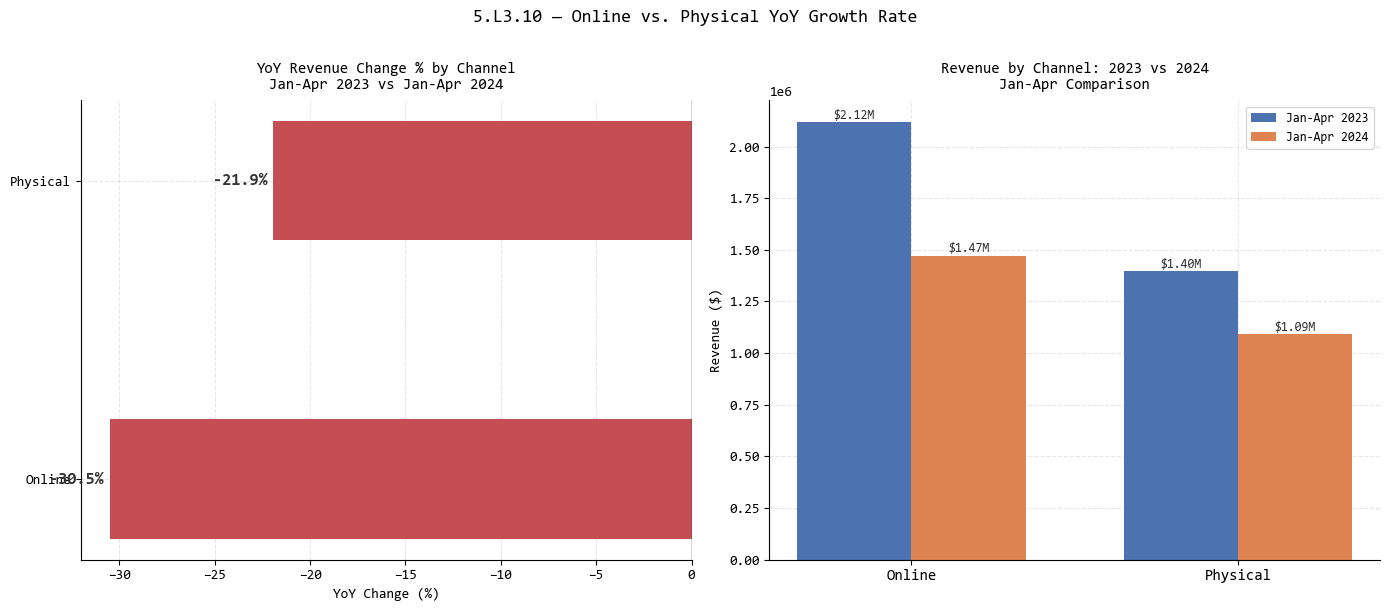

Online: 2,117,975 -> 1,471,950 | YoY -30.5%
Physical: 1,396,286 -> 1,090,044 | YoY -21.9%


In [ ]:
# 5.L3.10 - YoY growth rate by channel Jan-Apr 2023 vs 2024 (reuse df_channel from cell 0)
yoy = df_channel.pivot_table(index='Channel', columns='Year', values='Revenue').reset_index()
yoy.columns = ['Channel', 'Rev2023', 'Rev2024']
yoy['YoY_Pct'] = (yoy['Rev2024'] - yoy['Rev2023']) / yoy['Rev2023'] * 100
yoy['YoY_Abs'] = yoy['Rev2024'] - yoy['Rev2023']
yoy = yoy.sort_values('YoY_Pct')

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# YoY % by channel
ax = axes[0]
colors = ['#55A868' if v >= 0 else '#C44E52' for v in yoy['YoY_Pct']]
bars = ax.barh(yoy['Channel'], yoy['YoY_Pct'], color=colors, height=0.4)
ax.axvline(0, color='#333333', linewidth=1)
for bar, v in zip(bars, yoy['YoY_Pct']):
    offset = 0.3 if v >= 0 else -0.3
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', ha=ha, va='center', fontsize=12, color='#333333', fontfamily='Consolas', fontweight='bold')
ax.set_title('YoY Revenue Change % by Channel\nJan-Apr 2023 vs Jan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=8)
ax.set_xlabel('YoY Change (%)', fontsize=10)

# Absolute revenue both years
ax2 = axes[1]
CATPAL = ["#4C72B0","#DD8452"]
width = 0.35
channels = yoy['Channel'].tolist()
x = range(len(channels))
bars1 = ax2.bar([i - width/2 for i in x], yoy['Rev2023'], width, label='Jan-Apr 2023', color=CATPAL[0])
bars2 = ax2.bar([i + width/2 for i in x], yoy['Rev2024'], width, label='Jan-Apr 2024', color=CATPAL[1])
for bar, v in zip(list(bars1)+list(bars2), list(yoy['Rev2023'])+list(yoy['Rev2024'])):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000, f'${v/1e6:.2f}M',
             ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')
ax2.set_xticks(list(x))
ax2.set_xticklabels(channels, fontsize=11)
ax2.set_title('Revenue by Channel: 2023 vs 2024\nJan-Apr Comparison', fontsize=11, fontfamily='Consolas', pad=8)
ax2.set_ylabel('Revenue ($)', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('5.L3.10 — Online vs. Physical YoY Growth Rate', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

for _, row in yoy.iterrows():
    print(f"{row['Channel']}: {row['Rev2023']:,.0f} -> {row['Rev2024']:,.0f} | YoY {row['YoY_Pct']:+.1f}%")

### Key Insight — 5.L3.10
**The online channel is declining faster than physical stores: -30.5% YoY vs. -21.9% for physical (Jan-Apr 2023 to Jan-Apr 2024). In absolute terms, online lost $646K and physical lost $306K — meaning the channel that was supposed to be the growth engine is the one contracting most sharply.**
This -30.5% online decline is especially concerning because online had a much higher revenue base ($2.12M vs $1.40M in 2023) — so a faster proportional decline from a higher base translates into a much larger absolute loss. The 8.6 percentage point gap in decline rates between online (-30.5%) and physical (-21.9%) suggests that either the online channel had a significant one-off boost in early 2023 (making the base artificially high) or that physical stores are relatively more resilient due to local customer relationships and in-store experience.
Action priority: online channel recovery should be the top commercial priority, given its outsized contribution to total revenue loss.

> **Analysis Limitation:** YoY comparison is bounded to Jan-Apr to ensure a fair like-for-like window. The full-year decline rate may differ as later months in 2023 (which had the post-April cliff) would not be included in the comparator.